In [1]:
import pandas as pd
import numpy as nd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import pandas as pd
df = pd.read_excel("/content/Telco Churn Analysis.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df.isna().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [8]:
columns_to_remove = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df = df.drop(columns=columns_to_remove)

print("Columns remaining:")
print(df.columns.tolist())

Columns remaining:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'CLTV']


In [9]:
df.describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


In [10]:
df['Tenure Months'].value_counts()

,count
Tenure Months,
1,613
72,362
2,238
3,200
4,176
...,...
28,57
39,56
44,51


In [11]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,5306
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,2140
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,5560
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,2793


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [13]:
from sklearn.preprocessing import LabelEncoder


In [14]:
label_encoders = {}

for column in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

In [15]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,157,1,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,925,1,2701
2,0,0,0,1,8,1,2,1,0,0,...,0,2,2,0,1,2,99.65,6104,1,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,2,2,0,1,2,104.80,2646,1,5003
4,1,0,0,1,49,1,2,1,0,2,...,0,2,2,0,1,0,103.70,4265,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,72,1,0,2,1,1,...,1,1,1,2,1,0,21.15,770,0,5306
7039,1,0,1,1,24,1,2,0,2,0,...,2,2,2,1,1,3,84.80,1597,0,2140
7040,0,0,1,1,72,1,2,1,0,2,...,0,2,2,1,1,1,103.20,5698,0,5560
7041,0,0,1,1,11,0,1,0,2,0,...,0,0,0,0,1,2,29.60,2994,0,2793


SPLIT DATA

In [16]:
# X = input/features
X = df.drop("Churn Label", axis=1)

# y = target
y = df["Churn Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)


In [18]:
X_train.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
4626,1,0,0,0,35,0,1,0,0,0,2,0,2,2,0,0,2,49.20,1201,2782
4192,1,0,1,1,15,1,0,1,2,0,0,0,0,0,0,0,3,75.10,288,4634
5457,1,0,1,1,13,0,1,0,2,2,0,2,0,0,2,0,3,40.55,4847,2898
4717,0,0,1,0,26,1,0,0,0,2,2,0,2,2,2,1,1,73.50,1505,3596
4673,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,2,44.55,3743,3408


In [19]:
X_train.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
4626,1,0,0,0,35,0,1,0,0,0,2,0,2,2,0,0,2,49.20,1201,2782
4192,1,0,1,1,15,1,0,1,2,0,0,0,0,0,0,0,3,75.10,288,4634
5457,1,0,1,1,13,0,1,0,2,2,0,2,0,0,2,0,3,40.55,4847,2898
4717,0,0,1,0,26,1,0,0,0,2,2,0,2,2,2,1,1,73.50,1505,3596
4673,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,2,44.55,3743,3408


In [20]:
y_test.head()

,Churn Label
2196,0
3549,0
3515,0
5162,0
4642,0


In [21]:
y_train.head()

,Churn Label
4626,0
4192,0
5457,0
4717,0
4673,0


STANDARDIZE THE DATA

In [22]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test)

TRAIN LOGISTIC REGRESSION

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
log = LogisticRegression()

In [25]:
log.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

MAKE PREDICTIONS

In [26]:
pred = log.predict(X_test)

In [27]:
pred

array([0, 1, 0, ..., 0, 0, 0])

In [28]:
y_test.values

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
new = {"pred": pred, "y_test": y_test.values}

Performance Metrics

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Hyperparameter Tunning

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
log_param = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

In [34]:
grid = GridSearchCV(log, log_param, cv=5, scoring="f1")

In [35]:
grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='f1')

In [36]:
grid.best_estimator_

LogisticRegression(C=10)

In [37]:
grid_pred = grid.predict(X_test)

In [38]:
print(classification_report(y_test, grid_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Data Normalization

In [39]:
from imblearn.over_sampling import SMOTE

In [40]:
sm = SMOTE(random_state=42)

In [41]:
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [42]:
y_train_resampled.value_counts()

,count
Churn Label,
0,4139
1,4139


In [43]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
scaler = MinMaxScaler()

In [46]:
scaled_X_train = scaler.fit_transform(X_train_new)
scaled_X_test = scaler.transform(X_test_new)

In [47]:
logistic = LogisticRegression()

In [48]:
logistic.fit(scaled_X_train, y_train_new)

LogisticRegression()

In [49]:
pred_new = logistic.predict(scaled_X_test)

In [50]:
print(classification_report(y_test_new, pred_new))

              precision    recall  f1-score   support

           0       0.85      0.78      0.81       827
           1       0.79      0.87      0.83       829

    accuracy                           0.82      1656
   macro avg       0.82      0.82      0.82      1656
weighted avg       0.82      0.82      0.82      1656



Confusion Matrix:
[[641 186]
 [109 720]]


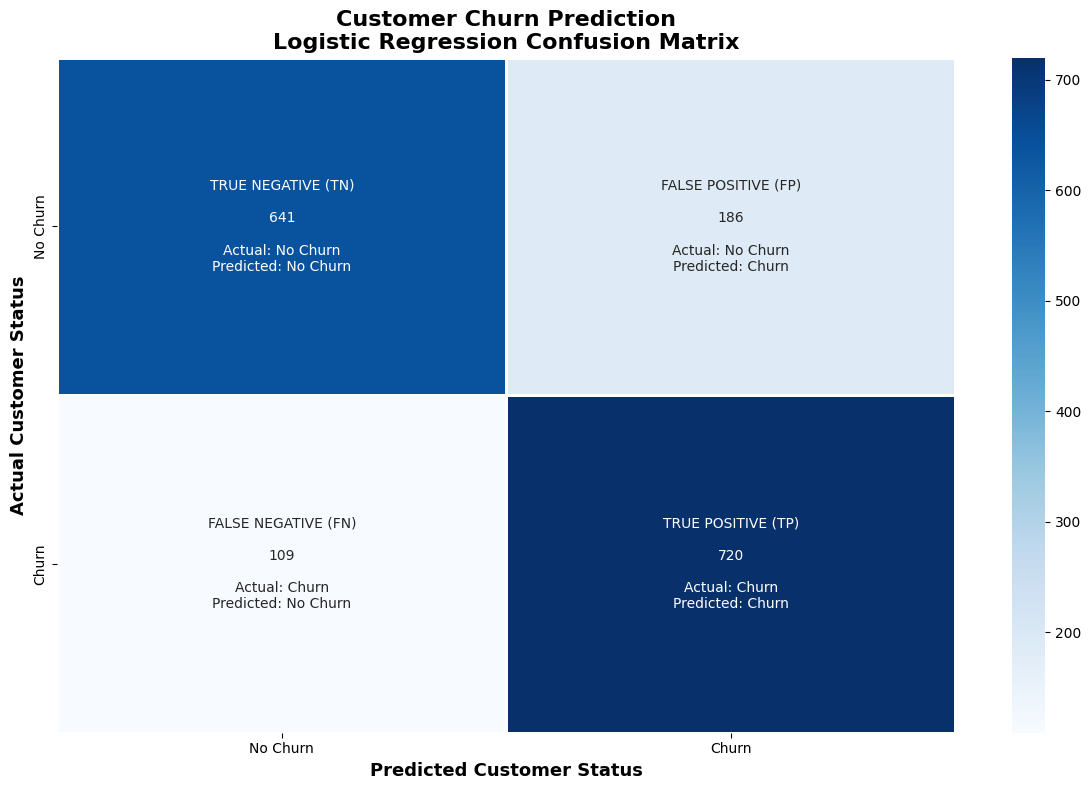

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test_new, pred_new)

# Extract TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

# Create explanatory labels for each cell
labels = [
    [
        f"TRUE NEGATIVE (TN)\n\n{TN}\n\n"
        "Actual: No Churn\n"
        "Predicted: No Churn",

        f"FALSE POSITIVE (FP)\n\n{FP}\n\n"
        "Actual: No Churn\n"
        "Predicted: Churn"
    ],

    [
        f"FALSE NEGATIVE (FN)\n\n{FN}\n\n"
        "Actual: Churn\n"
        "Predicted: No Churn",

        f"TRUE POSITIVE (TP)\n\n{TP}\n\n"
        "Actual: Churn\n"
        "Predicted: Churn"
    ]
]

# Create the plot
plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=2,
    linecolor="white",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    cbar=True
)

plt.title(
    "Customer Churn Prediction\n"
    "Logistic Regression Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Customer Status",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Actual Customer Status",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [53]:
import joblib

churn_model = {
    "model": log,
    "scaler": scaler,
    "label_encoders": label_encoders
}

joblib.dump(
    churn_model,
    "customer_churn_prediction.pkl"
)

print("Customer churn model saved successfully!")

Customer churn model saved successfully!
